In [1]:
import sys
print(sys.executable)

/Users/apple/BerTopic/.venv/bin/python


In [2]:
from bertopic.representation import KeyBERTInspired
from bertopic.representation import MaximalMarginalRelevance
from bertopic.representation import OpenAI
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans
import hdbscan
import umap
from sentence_transformers import SentenceTransformer
import json
import openai
import os
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from dotenv import load_dotenv

/Users/apple/BerTopic/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
api_key = "sk-c09e989569504c679f1b8e5361c1c3d7"
base_url = "https://dashscope.aliyuncs.com/compatible-mode/v1"

In [21]:
base_url

'https://dashscope.aliyuncs.com/compatible-mode/v1'

In [4]:
def create_cloud(model, channel, topic_id):
    topic_repr = model.get_topic(topic_id, full=True)
    values = topic_repr[channel]
    text = {word: value for word, value in values}
    wc = WordCloud(background_color="white", max_words=1000)
    wc.generate_from_frequencies(text)
    print(text)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show(block=True)

In [5]:
UMAP_N = 5
UMAP_DIST = 0.01
umap_model = umap.UMAP(
    n_neighbors=UMAP_N,
    min_dist=UMAP_DIST, 
    random_state=0
)

In [6]:
# HDBSCAN 聚类
MIN_CLUSTER_SIZE= 15
MIN_SAMPLES = 5
clustering_model = hdbscan.HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    metric='euclidean',
    cluster_selection_method='eom',
    min_samples=MIN_SAMPLES,
    prediction_data=True
)

In [7]:
# Kmeans
N_CLUSTER = 5
clustering_model = KMeans(
    n_clusters=N_CLUSTER,
    random_state=0
)

In [8]:
# 先embedding, 再移除停用词
vectorizer_model = CountVectorizer(
		max_df=0.8, 
		stop_words="english"
)

### 混合表示

In [9]:
prompt = """
  你会收到一个主题的关键词和代表文档。
  请输出“恰好一句话”总结该主题核心内容。
  输出语言和[DOCUMENTS]保持一致.
  不要标题，不要列表，不要解释。

  关键词:
  [KEYWORDS]

  代表文档:
  [DOCUMENTS]

  按下面格式输出：
  "a short label of the topic": <one-sentence summary>
"""

In [10]:
# representation_model = KeyBERTInspired()
client = openai.OpenAI(api_key = api_key, base_url = base_url)
main_model = OpenAI(
    client,
    model="glm-4.7",
    prompt= prompt,
    nr_docs=8,
    diversity=0.5,
    timeout=300
)

In [11]:
aspect_model_1 =  [KeyBERTInspired(top_n_words=30), MaximalMarginalRelevance(diversity=.5)]

In [12]:
representation_model = {
    "Main": main_model,
    "Aspect1": aspect_model_1
}

In [25]:
representation_model = main_model

In [13]:
MODEL_NAME = "all-MiniLM-L6-v2"
try:
    emb_minilm = SentenceTransformer(MODEL_NAME, local_files_only=True)
except OSError:
    emb_minilm = SentenceTransformer(MODEL_NAME)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 48448.28it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [14]:
bertopic = BERTopic(
    embedding_model=emb_minilm,   
    umap_model=umap_model,
    hdbscan_model=clustering_model,
    vectorizer_model=vectorizer_model,
    representation_model={
        "LLM": main_model,
        "Main": [KeyBERTInspired(top_n_words=30), MaximalMarginalRelevance(diversity=.5)]
    },
)

In [15]:
docs: list[str] = None
with open("data/technologyreview_texts.json", "r", encoding = "utf-8") as f:
    response = json.load(f)
    texts = response.get("texts", None)
    docs = [text["content_text"] for text in texts]

In [16]:
embeddings = emb_minilm.encode(docs, show_progress_bar=False)


In [17]:
embeddings

array([[-0.05444141, -0.1003436 , -0.04740569, ..., -0.03874551,
        -0.02617173, -0.0574111 ],
       [-0.0886429 , -0.0384105 , -0.05232496, ...,  0.01337701,
         0.00590229, -0.04139996],
       [-0.01634169, -0.06224858,  0.07511833, ...,  0.03264529,
        -0.05728213, -0.03807043],
       ...,
       [-0.05738383,  0.04100792, -0.01473988, ..., -0.01049973,
        -0.02024231, -0.04038643],
       [-0.00099286, -0.01621209, -0.0394801 , ...,  0.03994299,
         0.10145435, -0.05507377],
       [-0.00168493, -0.07413012, -0.0006026 , ..., -0.15906937,
         0.03260282, -0.0220777 ]], shape=(100, 384), dtype=float32)

In [17]:
model = bertopic.fit(docs, embeddings)

### 数据分析

In [18]:
# topics, probs = model.transform(docs, embeddings)
document = model.get_document_info(docs)
topics_info = model.get_topic_info()



In [19]:
topics_info

,Topic,Count,Name,Representation,LLM,Representative_Docs
0,0,23,0_martian_nasa_rover_robots,"[martian, nasa, rover, robots, drone, darwin, ...","[""火星样本返回竞赛"": 美国NASA的火星样本返回任务因资金和政治支持危机陷入停滞，而中国...","[This is today’s edition of The Download, our ..."
1,1,22,1_reactors_waste_computing_quantum,"[reactors, waste, computing, quantum, q4bio, b...","[""Technological Advancements"": The provided te...",[The prospect of making trash useful is always...
2,2,21,2_wildfires_smugglers_cameras_radar,"[wildfires, smugglers, cameras, radar, narco, ...","[""Tech-Driven Crime and Enforcement"": From aut...","[On a bright morning last April, a surveillanc..."
3,3,20,3_industrial_automation_robots_agents,"[industrial, automation, robots, agents, impro...","[""Industrial Innovation and AI Transformation""...","[In the race to adopt and show value from AI, ..."
4,4,14,4_fda_psychedelics_psilocybin_medications,"[fda, psychedelics, psilocybin, medications, p...","[""Contemporary Science and Health Updates"": Th...",[This week I want to look at where we are with...


{'Main': [('martian', np.float32(0.4321888)), ('nasa', np.float32(0.40003705)), ('rover', np.float32(0.37161413)), ('robots', np.float32(0.3374165)), ('drone', np.float32(0.30416068)), ('darwin', np.float32(0.24172892)), ('rocks', np.float32(0.23487636)), ('missions', np.float32(0.23437504)), ('dna', np.float32(0.20874217)), ('xai', np.float32(0.19567221))], 'LLM': [('"火星样本返回竞赛": 美国NASA的火星样本返回任务因资金和政治支持危机陷入停滞，而中国正加快推进天问三号计划，可能率先带回可能含有生命迹象的火星岩石样本。', 1)]}
{'wildfires': np.float32(0.43866104), 'smugglers': np.float32(0.335871), 'cameras': np.float32(0.32575947), 'radar': np.float32(0.27678406), 'narco': np.float32(0.24068676), 'officers': np.float32(0.2378002), 'government': np.float32(0.22137684), 'rainforest': np.float32(0.21548897), 'tools': np.float32(0.20455429), 'strikes': np.float32(0.1978668)}


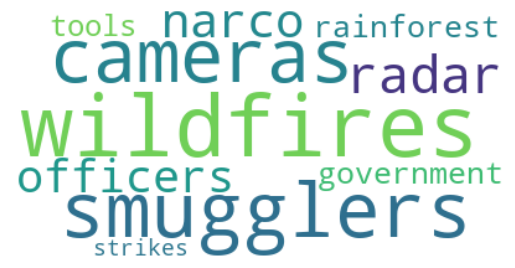

In [20]:
print(model.get_topic(0, full=True))
create_cloud(model, channel="Main", topic_id=2)

In [29]:
topics_info.to_csv("topics.csv", index = False)

In [30]:
print(document.iloc[:, 1:])

    Topic                                          Name  \
0       3           3_robots_automated_agentic_autonomy   
1       2               2_mars_rover_robots_exploration   
2       2               2_mars_rover_robots_exploration   
3       7          7_wildfires_preventing_storms_clouds   
4       8            8_deepmind_pets_sentience_advocacy   
..    ...                                           ...   
95      1              1_police_smugglers_cameras_drone   
96      9       9_reactors_waste_fuels_technologyreview   
97      1              1_police_smugglers_cameras_drone   
98      3           3_robots_automated_agentic_autonomy   
99      0  0_hardware_innovation_industrial_engineering   

                                       Representation  \
0   [robots, automated, agentic, autonomy, enterpr...   
1   [mars, rover, robots, exploration, rocks, alie...   
2   [mars, rover, robots, exploration, rocks, alie...   
3   [wildfires, preventing, storms, clouds, snowfl...   
4   [d

In [21]:
model.visualize_topics()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'customdata': array([[0, 'martian | nasa | rover | robots | drone', 23],
                                   [1, 'reactors | waste | computing | quantum | q4bio', 22],
                                   [2, 'wildfires | smugglers | cameras | radar | narco', 21],
                                   [3, 'industrial | automation | robots | agents | improving', 20],
                                   [4, 'fda | psychedelics | psilocybin | medications | peptides', 14]],
                                  dtype=object),
              'hovertemplate': '<b>Topic %{customdata[0]}</b><br>%{customdata[1]}<br>Size: %{customdata[2]}',
              'legendgroup': '',
              'marker': {'color': '#B0BEC5',
                         'line': {'color': 'DarkSlateGrey', 'width': 2},
                         'size': {'bdata': 'FxYVFA4=', 'dtype': 'i1'},
                         'sizemode': 'area',
                         'sizeref': 0.014375,
                         'symbol': 'circle'},
              'mode': 'markers',
              'name': '',
              'orientation': 'v',
              'showlegend': False,
              'type': 'scatter',
              'x': {'bdata': 'x7KDwaCwAEERfYDB31EIQTy89EA=', 'dtype': 'f4'},
              'xaxis': 'x',
              'y': {'bdata': 'PEGiQXFnJUGcC59BS+gdQTG8K0E=', 'dtype': 'f4'},
              'yaxis': 'y'}],
    'layout': {'annotations': [{'showarrow': False,
                                'text': 'D1',
                                'x': np.float32(-18.931637),
                                'y': np.float32(15.856481),
                                'yshift': 10},
                               {'showarrow': False,
                                'text': 'D2',
                                'x': np.float32(-4.5668254),
                                'xshift': 10,
                                'y': np.float32(23.324131)}],
               'height': 650,
               'hoverlabel': {'bgcolor': 'white', 'font': {'family': 'Rockwell', 'size': 16}},
               'legend': {'itemsizing': 'constant', 'tracegroupgap': 0},
               'margin': {'t': 60},
               'shapes': [{'line': {'color': '#CFD8DC', 'width': 2},
                           'type': 'line',
                           'x0': np.float32(-4.5668254),
                           'x1': np.float32(-4.5668254),
                           'y0': np.float32(8.38883),
                           'y1': np.float32(23.324131)},
                          {'line': {'color': '#9E9E9E', 'width': 2},
                           'type': 'line',
                           'x0': np.float32(-18.931637),
                           'x1': np.float32(9.797986),
                           'y0': np.float32(15.856481),
                           'y1': np.float32(15.856481)}],
               'sliders': [{'active': 0,
                            'pad': {'t': 50},
                            'steps': [{'args': [{'marker.color': [['red', '#B0BEC5', '#B0BEC5', '#B0BEC5', '#B0BEC5']]}],
                                       'label': 'Topic 0',
                                       'method': 'update'},
                                      {'args': [{'marker.color': [['#B0BEC5', 'red', '#B0BEC5', '#B0BEC5', '#B0BEC5']]}],
                                       'label': 'Topic 1',
                                       'method': 'update'},
                                      {'args': [{'marker.color': [['#B0BEC5', '#B0BEC5', 'red', '#B0BEC5', '#B0BEC5']]}],
                                       'label': 'Topic 2',
                                       'method': 'update'},
                                      {'args': [{'marker.color': [['#B0BEC5', '#B0BEC5', '#B0BEC5', 'red', '#B0BEC5']]}],
                                       'label': 'Topic 3',
                                       'method': 'update'},
                                      {'args': [{'marker.color': [['#B0BEC5', '#B0BEC5', '#B0BEC5', '#B0BEC5', 'red']]}],
   

In [22]:
model.visualize_barchart()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'marker': {'color': '#D55E00'},
              'orientation': 'h',
              'type': 'bar',
              'x': [0.3041606843471527, 0.33741649985313416, 0.37161412835121155,
                    0.4000370502471924, 0.43218880891799927],
              'xaxis': 'x',
              'y': [drone  , robots  , rover  , nasa  , martian  ],
              'yaxis': 'y'},
             {'marker': {'color': '#0072B2'},
              'orientation': 'h',
              'type': 'bar',
              'x': [0.2113942950963974, 0.23539353907108307, 0.2638454735279083,
                    0.45805519819259644, 0.4636082947254181],
              'xaxis': 'x2',
              'y': [q4bio  , quantum  , computing  , waste  , reactors  ],
              'yaxis': 'y2'},
             {'marker': {'color': '#CC79A7'},
              'orientation': 'h',
              'type': 'bar',
              'x': [0.24068675935268402, 0.2767840623855591, 0.3257594704627991,
                    0.33587101101875305, 0.43866103887557983],
              'xaxis': 'x3',
              'y': [narco  , radar  , cameras  , smugglers  , wildfires  ],
              'yaxis': 'y3'},
             {'marker': {'color': '#E69F00'},
              'orientation': 'h',
              'type': 'bar',
              'x': [0.2734697461128235, 0.4003114402294159, 0.40328842401504517,
                    0.42482587695121765, 0.4466826021671295],
              'xaxis': 'x4',
              'y': [improving  , agents  , robots  , automation  , industrial  ],
              'yaxis': 'y4'},
             {'marker': {'color': '#56B4E9'},
              'orientation': 'h',
              'type': 'bar',
              'x': [0.3432425260543823, 0.35464003682136536, 0.3925339877605438,
                    0.4069620370864868, 0.4218742251396179],
              'xaxis': 'x5',
              'y': [peptides  , medications  , psilocybin  , psychedelics  , fda
                    ],
              'yaxis': 'y5'}],
    'layout': {'annotations': [{'font': {'size': 16},
                                'showarrow': False,
                                'text': 'Topic 0',
                                'x': 0.0875,
                                'xanchor': 'center',
                                'xref': 'paper',
                                'y': 1.0,
                                'yanchor': 'bottom',
                                'yref': 'paper'},
                               {'font': {'size': 16},
                                'showarrow': False,
                                'text': 'Topic 1',
                                'x': 0.36250000000000004,
                                'xanchor': 'center',
                                'xref': 'paper',
                                'y': 1.0,
                                'yanchor': 'bottom',
                                'yref': 'paper'},
                               {'font': {'size': 16},
                                'showarrow': False,
                                'text': 'Topic 2',
                                'x': 0.6375000000000001,
                                'xanchor': 'center',
                                'xref': 'paper',
                                'y': 1.0,
                                'yanchor': 'bottom',
                                'yref': 'paper'},
                               {'font': {'size': 16},
                                'showarrow': False,
                                'text': 'Topic 3',
                                'x': 0.9125,
                                'xanchor': 'center',
                                'xref': 'paper',
                                'y': 1.0,
                                'yanchor': 'bottom',
                                'yref': 'paper'},
                               {'font': {'size': 16},
                                'showarrow': False,
                                'text': 'Topic 4',
                                'x': 0.0875,
        

In [23]:
model.topic_labels_, model.topic_aspects_

({0: '0_martian_nasa_rover_robots',
  1: '1_reactors_waste_computing_quantum',
  2: '2_wildfires_smugglers_cameras_radar',
  3: '3_industrial_automation_robots_agents',
  4: '4_fda_psychedelics_psilocybin_medications'},
 {'LLM': {0: [('"火星样本返回竞赛": 美国NASA的火星样本返回任务因资金和政治支持危机陷入停滞，而中国正加快推进天问三号计划，可能率先带回可能含有生命迹象的火星岩石样本。',
     1)],
   1: [('"Technological Advancements": The provided texts explore a diverse range of technological developments, including AI\'s transformation of strategy games and personal archiving, the challenges of nuclear waste management and battery innovation, and the ongoing quest for practical quantum computing applications.',
     1)],
   2: [('"Tech-Driven Crime and Enforcement": From autonomous narco submarines and citywide surveillance networks to cloud seeding for wildfire prevention and digital forensics, modern technologies are fundamentally altering the landscape of crime, law enforcement, and environmental protection.',
     1)],
   3: [('"Industrial Innovation

In [24]:
from pathlib import Path
import json

In [25]:
file_path = "data/analysis.json"
with open(file_path, 'w', encoding='utf-8') as f:
    json.dump(model.topic_aspects_, f, indent=4, ensure_ascii=False)

In [35]:
model.visualize_heatmap()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'coloraxis': 'coloraxis',
              'hovertemplate': 'x: %{x}<br>y: %{y}<br>Similarity Score: %{z}<extra></extra>',
              'name': '0',
              'type': 'heatmap',
              'x': [0_hardware_innovation_indus..., 1_police_smugglers_cameras,
                    2_mars_rover_robots, 3_robots_automated_agentic,
                    4_peptide_fda_psilocybin, 5_batteries_industry_openclaw,
                    6_drones_chatbots_surveilla..., 7_wildfires_preventing_storms,
                    8_deepmind_pets_sentience, 9_reactors_waste_fuels],
              'xaxis': 'x',
              'y': [0_hardware_innovation_indus..., 1_police_smugglers_cameras,
                    2_mars_rover_robots, 3_robots_automated_agentic,
                    4_peptide_fda_psilocybin, 5_batteries_industry_openclaw,
                    6_drones_chatbots_surveilla..., 7_wildfires_preventing_storms,
                    8_deepmind_pets_sentience, 9_reactors_waste_fuels],
              'yaxis': 'y',
              'z': {'bdata': ('//9/P4Uf0D78vgU/WJIWPwJxwz4wzy' ... '7BSis/0oMUP8P58j6gZgI/AQCAPw=='),
                    'dtype': 'f4',
                    'shape': '10, 10'}}],
    'layout': {'coloraxis': {'colorbar': {'title': {'text': 'Similarity Score'}},
                             'colorscale': [[0.0, 'rgb(247,252,240)'], [0.125,
                                            'rgb(224,243,219)'], [0.25,
                                            'rgb(204,235,197)'], [0.375,
                                            'rgb(168,221,181)'], [0.5,
                                            'rgb(123,204,196)'], [0.625,
                                            'rgb(78,179,211)'], [0.75,
                                            'rgb(43,140,190)'], [0.875,
                                            'rgb(8,104,172)'], [1.0,
                                            'rgb(8,64,129)']]},
               'height': 800,
               'hoverlabel': {'bgcolor': 'white', 'font': {'family': 'Rockwell', 'size': 16}},
               'legend': {'title': {'text': 'Trend'}},
               'margin': {'t': 60},
               'showlegend': True,
               'template': '...',
               'title': {'font': {'color': 'Black', 'size': 22},
                         'text': '<b>Similarity Matrix</b>',
                         'x': 0.55,
                         'xanchor': 'center',
                         'y': 0.95,
                         'yanchor': 'top'},
               'width': 800,
               'xaxis': {'anchor': 'y', 'constrain': 'domain', 'domain': [0.0, 1.0], 'scaleanchor': 'y'},
               'yaxis': {'anchor': 'x', 'autorange': 'reversed', 'constrain': 'domain', 'domain': [0.0, 1.0]}}
})

In [36]:
model.visualize_hierarchy()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hoverinfo': 'text',
              'marker': {'color': 'rgb(61,153,112)'},
              'mode': 'lines',
              'type': 'scatter',
              'x': {'bdata': 'AAAAAAAAAAAwTxzMaB7nPzBPHMxoHuc/AAAAAAAAAAA=', 'dtype': 'f8'},
              'xaxis': 'x',
              'y': {'bdata': 'AAAAAAAALsAAAAAAAAAuwAAAAAAAADnAAAAAAAAAOcA=', 'dtype': 'f8'},
              'yaxis': 'y'},
             {'hoverinfo': 'text',
              'marker': {'color': 'rgb(61,153,112)'},
              'mode': 'lines',
              'type': 'scatter',
              'x': {'bdata': 'AAAAAAAAAABq5tqPLTTpP2rm2o8tNOk/AAAAAAAAAAA=', 'dtype': 'f8'},
              'xaxis': 'x',
              'y': {'bdata': 'AAAAAACARsAAAAAAAIBGwAAAAAAAgEvAAAAAAACAS8A=', 'dtype': 'f8'},
              'yaxis': 'y'},
             {'hoverinfo': 'text',
              'marker': {'color': 'rgb(61,153,112)'},
              'mode': 'lines',
              'type': 'scatter',
              'x': {'bdata': 'AAAAAAAAAADQCpcR/C3qP9AKlxH8Leo/aubajy006T8=', 'dtype': 'f8'},
              'xaxis': 'x',
              'y': {'bdata': 'AAAAAACAQcAAAAAAAIBBwAAAAAAAAEnAAAAAAAAAScA=', 'dtype': 'f8'},
              'yaxis': 'y'},
             {'hoverinfo': 'text',
              'marker': {'color': 'rgb(61,153,112)'},
              'mode': 'lines',
              'type': 'scatter',
              'x': {'bdata': 'AAAAAAAAAABvkrwBd6vlP2+SvAF3q+U/AAAAAAAAAAA=', 'dtype': 'f8'},
              'xaxis': 'x',
              'y': {'bdata': 'AAAAAABAUMAAAAAAAEBQwAAAAAAAwFLAAAAAAADAUsA=', 'dtype': 'f8'},
              'yaxis': 'y'},
             {'hoverinfo': 'text',
              'marker': {'color': 'rgb(61,153,112)'},
              'mode': 'lines',
              'type': 'scatter',
              'x': {'bdata': 'b5K8AXer5T82diN9UB7pPzZ2I31QHuk/AAAAAAAAAAA=', 'dtype': 'f8'},
              'xaxis': 'x',
              'y': {'bdata': 'AAAAAACAUcAAAAAAAIBRwAAAAAAAQFXAAAAAAABAVcA=', 'dtype': 'f8'},
              'yaxis': 'y'},
             {'hoverinfo': 'text',
              'marker': {'color': 'rgb(61,153,112)'},
              'mode': 'lines',
              'type': 'scatter',
              'x': {'bdata': '0AqXEfwt6j8kWKtCuL7qPyRYq0K4vuo/NnYjfVAe6T8=', 'dtype': 'f8'},
              'xaxis': 'x',
              'y': {'bdata': 'AAAAAABARcAAAAAAAEBFwAAAAAAAYFPAAAAAAABgU8A=', 'dtype': 'f8'},
              'yaxis': 'y'},
             {'hoverinfo': 'text',
              'marker': {'color': 'rgb(61,153,112)'},
              'mode': 'lines',
              'type': 'scatter',
              'x': {'bdata': 'JFirQri+6j/X2C2nOJvsP9fYLac4m+w/AAAAAAAAAAA=', 'dtype': 'f8'},
              'xaxis': 'x',
              'y': {'bdata': 'AAAAAAAATsAAAAAAAABOwAAAAAAAwFfAAAAAAADAV8A=', 'dtype': 'f8'},
              'yaxis': 'y'},
             {'hoverinfo': 'text',
              'marker': {'color': 'rgb(61,153,112)'},
              'mode': 'lines',
              'type': 'scatter',
              'x': {'bdata': 'ME8czGge5z9Mq10sjFXtP0yrXSyMVe0/19gtpzib7D8=', 'dtype': 'f8'},
              'xaxis': 'x',
              'y': {'bdata': 'AAAAAAAANMAAAAAAAAA0wAAAAAAAYFPAAAAAAABgU8A=', 'dtype': 'f8'},
              'yaxis': 'y'},
             {'hoverinfo': 'text',
              'marker': {'color': 'rgb(61,153,112)'},
              'mode': 'lines',
              'type': 'scatter',
              'x': {'bdata': 'AAAAAAAAAADhDU9G6qbtP+ENT0bqpu0/TKtdLIxV7T8=', 'dtype': 'f8'},
              'xaxis': 'x',
              'y': {'bdata': 'AAAAAAAAFMAAAAAAAAAUwAAAAAAAYEjAAAAAAABgSMA=', 'dtype': 'f8'},
              'yaxis': 'y'}],
    'layout': {'autosize': False,
               'height': 350,
               'hoverlabel': {'bgcolor': 'white', 'font': {'family': 'Rockwell', 'size': 16}},
               'hovermode': 'closest',
               'plot_bgcolor': '#ECEFF1',
               'showlegend': False,
               'template': '...',
               'title': {'font': {'color': 'Black', 'size': 22},
                         'text': '<b>Hierarchical C